# SIMM59 Lab 1: Text Cleaning and Tokenization

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cca-cce/osm-comm/blob/main/jnb/simm59/lecture-lab1/simm59_lab1.ipynb)

## Overview

This lab introduces the standard NLP preprocessing pipeline, following Ghosh & Gunning (2019), chapters 1–2. We begin with two minimal synthetic sentences to make each step transparent, then apply the same pipeline to a real corpus of nine Equinor sustainability documents.

**Learning objectives**
- Apply sentence segmentation, tokenization, stop word removal, normalization, and lemmatization using spaCy
- Build a tidy token DataFrame with one normalized token per row, indexed by document and sentence
- Explore token frequency distributions and visualize results with seaborn and matplotlib

**Tools:** Python · spaCy (`en_core_web_sm`) · pandas · seaborn · matplotlib

> **Reading:** Ghosh, S., & Gunning, D. (2019). *Natural Language Processing Fundamentals*. Packt Publishing. Chapters 1–2.

In [1]:
# ── Install spaCy English model (pre-installed in Colab, model may need download) ──
import subprocess, sys
subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_sm", "--quiet"],
               check=True, capture_output=True)

# ── Download course corpus from GitHub as a zip ────────────────────────────
import urllib.request, zipfile, os

url = "https://github.com/cca-cce/osm-comm/raw/refs/heads/main/res/edu/simm59/text-data.zip"
if not os.path.isdir("text-data"):
    print("Downloading corpus...")
    urllib.request.urlretrieve(url, "text-data.zip")
    with zipfile.ZipFile("text-data.zip") as zf:
        zf.extractall(".")
    txt_files = [f for f in os.listdir("text-data") if f.endswith(".txt")]
    print(f"Corpus ready: {len(txt_files)} files in text-data/")
else:
    print("text-data/ already present")

# ── Imports ────────────────────────────────────────────────────────────────
import spacy
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

nlp = spacy.load("en_core_web_sm")
sns.set_theme(style="whitegrid", palette="muted")
DATA_DIR = Path("text-data")
print(f"\nspaCy {spacy.__version__} · pandas {pd.__version__} · ready")

text-data/ already present

spaCy 3.8.11 · pandas 2.2.2 · ready


## 1. NLP: From Raw Text to Structured Data

Natural language processing (NLP) enables machines to understand and analyse human language. A core challenge is that raw text is **unstructured** — it does not arrive in the rows-and-columns format that quantitative methods require. Preprocessing converts text into structured representations suitable for computational analysis.

Ghosh & Gunning (2019, ch. 1) describe the standard NLP pipeline as a sequence of steps applied in order:

| Step | Purpose |
|------|---------|
| Sentence segmentation | Splits a document into sentences |
| Tokenization | Splits each sentence into words (tokens) |
| Stop word removal | Removes common, low-information words (*the*, *is*, *of*) |
| Normalization | Lowercases text; removes non-alphabetic characters |
| Lemmatization | Reduces tokens to their dictionary base form |

We begin with a **mini-corpus of two synthetic documents** — two sentences each — to make every pipeline decision visible before scaling up to real data.

In [2]:
# ── Two synthetic documents (our mini-corpus) ──────────────────────────────
# Each value is a short text with two sentences.
documents = {
    "doc_01": (
        "Companies are developing new strategies for reducing carbon emissions. "
        "The transition to renewable energy is accelerating across global markets."
    ),
    "doc_02": (
        "Regulators require firms to disclose environmental risks in their annual reports. "
        "Investors are increasingly demanding transparency on sustainability issues."
    ),
}

for doc_id, text in documents.items():
    print(f"[{doc_id}]\n{text}\n")

[doc_01]
Companies are developing new strategies for reducing carbon emissions. The transition to renewable energy is accelerating across global markets.

[doc_02]
Regulators require firms to disclose environmental risks in their annual reports. Investors are increasingly demanding transparency on sustainability issues.



## 2. Sentence Boundary Detection

Before tokenizing into words, we first segment each document into **sentences**. Many NLP analyses — co-occurrence statistics, concordances, sentiment scoring — operate at the sentence level, so preserving this structure matters.

Ghosh & Gunning (2019, ch. 1, "Sentence Boundary Detection") note that splitting on `.` is insufficient: periods appear inside abbreviations (*U.S.A.*), decimals (*3.14*), and titles (*Dr.*). spaCy uses a trained dependency parser to detect sentence boundaries robustly.

The result is `df_sentences_syn`: one row per sentence, with columns for document identity and sentence position. This hierarchical structure — document → sentence → token — is maintained throughout the lab.

In [3]:
# ── Sentence boundary detection ────────────────────────────────────────────
rows = []
for doc_id, text in documents.items():
    spacy_doc = nlp(text)
    for sent_num, sent in enumerate(spacy_doc.sents, start=1):
        rows.append({
            "doc_id":        doc_id,
            "sentence_id":   sent_num,
            "sentence_text": sent.text.strip(),
        })

df_sentences_syn = pd.DataFrame(rows)
display(df_sentences_syn)

,doc_id,sentence_id,sentence_text
0,doc_01,1,Companies are developing new strategies for re...
1,doc_01,2,The transition to renewable energy is accelera...
2,doc_02,1,Regulators require firms to disclose environme...
3,doc_02,2,Investors are increasingly demanding transpare...


## 3. Tokenization

**Tokenization** splits each sentence into individual units called *tokens* — typically words, but also punctuation marks and numbers. spaCy combines whitespace splitting with language-specific rules to handle edge cases (Ghosh & Gunning, 2019, ch. 1, "Tokenization"; ch. 2, "Cleaning Text Data"):

- **Contractions:** *don't* → *do* + *n't*
- **Attached punctuation:** *emissions.* → *emissions* + *.*
- **Hyphenated compounds:** handled according to language rules

At this stage we keep **all** tokens — including stop words and punctuation — to show what the raw tokenized output looks like before any filtering is applied. Comparing this output to later steps makes each filtering decision legible.

In [4]:
# ── Tokenization: all tokens before any filtering ─────────────────────────
print("Raw tokens per sentence (nothing removed yet):\n")
for _, row in df_sentences_syn.iterrows():
    doc = nlp(row["sentence_text"])
    tokens = [tok.text for tok in doc]
    print(f"  [{row['doc_id']} · sent {row['sentence_id']}]")
    print(f"  {tokens}\n")

Raw tokens per sentence (nothing removed yet):

  [doc_01 · sent 1]
  ['Companies', 'are', 'developing', 'new', 'strategies', 'for', 'reducing', 'carbon', 'emissions', '.']

  [doc_01 · sent 2]
  ['The', 'transition', 'to', 'renewable', 'energy', 'is', 'accelerating', 'across', 'global', 'markets', '.']

  [doc_02 · sent 1]
  ['Regulators', 'require', 'firms', 'to', 'disclose', 'environmental', 'risks', 'in', 'their', 'annual', 'reports', '.']

  [doc_02 · sent 2]
  ['Investors', 'are', 'increasingly', 'demanding', 'transparency', 'on', 'sustainability', 'issues', '.']



## 4. Stop Word Removal

**Stop words** are high-frequency function words — articles (*a*, *the*), prepositions (*in*, *of*, *for*), pronouns (*they*, *their*), and auxiliaries (*are*, *is*) — that appear in virtually every document and therefore contribute little to distinguishing one document's content from another (Ghosh & Gunning, 2019, ch. 1, "Stop Word Removal").

spaCy's English model includes 326 stop words. Each token carries an `.is_stop` attribute: `True` if the token is in the stop-word list.

> **Research decision:** Stop word removal is not always appropriate. If your research question concerns *how* something is said — hedging language, modality, syntactic complexity — stop words carry analytical meaning. For example, *may*, *could*, and *aims to* are stop-word-adjacent but central to a study of corporate commitment framing. Always justify preprocessing choices relative to your research question (see course module, Lab 1 description).

In [5]:
# ── Stop word removal ──────────────────────────────────────────────────────
print(f"spaCy has {len(nlp.Defaults.stop_words)} stop words. First 20 (alphabetical):\n")
print(sorted(nlp.Defaults.stop_words)[:20])

print("\nTokens remaining after stop word removal:\n")
for _, row in df_sentences_syn.iterrows():
    doc = nlp(row["sentence_text"])
    kept = [tok.text for tok in doc if not tok.is_stop]
    print(f"  [{row['doc_id']} · sent {row['sentence_id']}]: {kept}")

spaCy has 326 stop words. First 20 (alphabetical):

["'d", "'ll", "'m", "'re", "'s", "'ve", 'a', 'about', 'above', 'across', 'after', 'afterwards', 'again', 'against', 'all', 'almost', 'alone', 'along', 'already', 'also']

Tokens remaining after stop word removal:

  [doc_01 · sent 1]: ['Companies', 'developing', 'new', 'strategies', 'reducing', 'carbon', 'emissions', '.']
  [doc_01 · sent 2]: ['transition', 'renewable', 'energy', 'accelerating', 'global', 'markets', '.']
  [doc_02 · sent 1]: ['Regulators', 'require', 'firms', 'disclose', 'environmental', 'risks', 'annual', 'reports', '.']
  [doc_02 · sent 2]: ['Investors', 'increasingly', 'demanding', 'transparency', 'sustainability', 'issues', '.']


## 5. Text Normalization

**Normalization** standardizes the surface form of tokens so that the same word is not counted as multiple distinct types. Ghosh & Gunning (2019, ch. 1, "Text Normalization") describe the key operations:

- **Lowercasing:** *Companies* and *companies* are treated as the same type.
- **Alphabetic filter:** Punctuation marks (`.`, `,`), numbers, and special characters are discarded when only word content is of analytical interest.
- **Minimum length filter:** Very short tokens surviving the previous steps (e.g., single letters from parsing artefacts) are removed.

After this step, every token is a clean, lowercase alphabetic string of at least three characters.

> **Note:** What counts as "noise" depends entirely on the research question. A study of numerical claims in corporate reports would not discard numbers. A study of hashtags would preserve `#` characters. Preprocessing must serve the analysis — not the other way around.

In [6]:
# ── Normalization: lowercase + alphabetic filter + minimum length 3 ────────
print("Normalized tokens (stops removed · alpha only · len ≥ 3 · lowercased):\n")
for _, row in df_sentences_syn.iterrows():
    doc = nlp(row["sentence_text"])
    normalized = [
        tok.text.lower()
        for tok in doc
        if not tok.is_stop and tok.is_alpha and len(tok.text) >= 3
    ]
    print(f"  [{row['doc_id']} · sent {row['sentence_id']}]: {normalized}")

Normalized tokens (stops removed · alpha only · len ≥ 3 · lowercased):

  [doc_01 · sent 1]: ['companies', 'developing', 'new', 'strategies', 'reducing', 'carbon', 'emissions']
  [doc_01 · sent 2]: ['transition', 'renewable', 'energy', 'accelerating', 'global', 'markets']
  [doc_02 · sent 1]: ['regulators', 'require', 'firms', 'disclose', 'environmental', 'risks', 'annual', 'reports']
  [doc_02 · sent 2]: ['investors', 'increasingly', 'demanding', 'transparency', 'sustainability', 'issues']


## 6. Lemmatization vs. Stemming

After normalization, tokens still appear in their inflected forms: *reducing*, *accelerating*, *demanding*. We reduce each to its base form using either **stemming** or **lemmatization** (Ghosh & Gunning, 2019, ch. 1, pp. 15–17):

| Method | Mechanism | Output | Example |
|--------|-----------|--------|---------|
| **Stemming** | Heuristic suffix stripping | May not be a real word | *accelerating* → *acceler* |
| **Lemmatization** | Dictionary lookup + morphological analysis | Always a valid word | *accelerating* → *accelerate* |

spaCy performs **lemmatization** via `tok.lemma_`. NLTK's `PorterStemmer` is a classic rule-based stemmer. For most social science text analysis, lemmatization is preferable: it produces interpretable output and avoids merging unrelated words that share a surface stem (e.g., *universe* and *university* both stem to *univers* under Porter).

In [7]:
# ── Lemmatization vs. Porter stemming ─────────────────────────────────────
import nltk
from nltk.stem import PorterStemmer
nltk.download("punkt", quiet=True)
stemmer = PorterStemmer()

print(f"{'Original':<22} {'spaCy lemma':<22} {'Porter stem'}")
print("─" * 65)
for _, row in df_sentences_syn.iterrows():
    doc = nlp(row["sentence_text"])
    for tok in doc:
        if not tok.is_stop and tok.is_alpha and len(tok.text) >= 3:
            orig  = tok.text.lower()
            lemma = tok.lemma_.lower()
            stem  = stemmer.stem(orig)
            if orig != lemma or orig != stem:   # only show rows that change
                print(f"{orig:<22} {lemma:<22} {stem}")

Original               spaCy lemma            Porter stem
─────────────────────────────────────────────────────────────────
companies              company                compani
developing             develop                develop
strategies             strategy               strategi
reducing               reduce                 reduc
emissions              emission               emiss
transition             transition             transit
renewable              renewable              renew
energy                 energy                 energi
accelerating           accelerate             acceler
markets                market                 market
regulators             regulator              regul
require                require                requir
firms                  firm                   firm
disclose               disclose               disclos
environmental          environmental          environment
risks                  risk                   risk
reports                r

## 7. Building the Tidy Token DataFrame

We now combine all preprocessing steps into a **single pipeline function** and produce the central data structure of this lab: a tidy token DataFrame in which each row represents one normalized token.

The **tidy format** — one observation per row — is the standard for computational text analysis. It makes every subsequent operation a straightforward pandas `groupby`, `filter`, or `merge` (Ghosh & Gunning, 2019, ch. 2, "Cleaning Text Data"):

| Column | Content |
|--------|---------|
| `doc_id` | Source document identifier |
| `sentence_id` | Sentence position within the document |
| `token_id` | Token position within the sentence (after filtering) |
| `token` | Normalized, lemmatized token |

**Pipeline applied in order:**  
sentence segmentation → tokenization → stop word removal → alpha filter (len ≥ 3) → lowercasing → lemmatization

In [8]:
# ── Full preprocessing pipeline ────────────────────────────────────────────
def preprocess_to_tokens(doc_id, text, nlp_model, extra_stops=frozenset()):
    """Run the full NLP preprocessing pipeline on one document.

    Parameters
    ----------
    extra_stops : set, optional
        Additional stop words to filter out beyond spaCy's built-in list.
        Useful for removing corpus-specific artefacts (e.g. web UI fragments).

    Returns a list of dicts: {doc_id, sentence_id, token_id, token}.
    """
    rows = []
    spacy_doc = nlp_model(text)
    for sent_num, sent in enumerate(spacy_doc.sents, start=1):
        tok_num = 0
        for tok in sent:
            word = tok.lemma_.lower()
            if (not tok.is_stop
                    and word not in extra_stops
                    and tok.is_alpha
                    and len(tok.text) >= 3):
                tok_num += 1
                rows.append({
                    "doc_id":      doc_id,
                    "sentence_id": sent_num,
                    "token_id":    tok_num,
                    "token":       word,
                })
    return rows

# Apply to our synthetic mini-corpus (no extra stops needed here)
df_tokens_syn = pd.DataFrame(
    [row for doc_id, text in documents.items()
     for row in preprocess_to_tokens(doc_id, text, nlp)]
)
display(df_tokens_syn)

,doc_id,sentence_id,token_id,token
0,doc_01,1,1,company
1,doc_01,1,2,develop
2,doc_01,1,3,new
3,doc_01,1,4,strategy
4,doc_01,1,5,reduce
5,doc_01,1,6,carbon
6,doc_01,1,7,emission
7,doc_01,2,1,transition
8,doc_01,2,2,renewable
9,doc_01,2,3,energy


## 8. Inspecting the Synthetic Pipeline Output

The tidy DataFrame contains only content-bearing tokens in normalized, lemmatized form. From two documents with four sentences and roughly 60 raw tokens, the pipeline has extracted a compact set of analytically meaningful units.

The `doc_id` and `sentence_id` columns preserve the hierarchical structure of the original text. This means we can always zoom *in* to the sentence level (for concordancing) or zoom *out* to the document level (for frequency comparison).

**Reflection questions — try these before moving on:**
1. Which tokens were removed by stop word filtering? Are any of them analytically relevant for a sustainability study?
2. How does lemmatization change tokens like *requiring*, *developing*, *accelerating*? Check the `token` column against the original sentences.
3. How would the DataFrame change if you lowered the minimum length from 3 to 2?
4. Try replacing the two synthetic sentences with text from your own research area and re-run from cell 2.

In [9]:
# ── Inspect the synthetic output ───────────────────────────────────────────
print("DataFrame shape:", df_tokens_syn.shape)

print("\nToken count per document:")
display(df_tokens_syn.groupby("doc_id")["token"].count().reset_index(name="n_tokens"))

print("\nAll unique lemmatized tokens across the mini-corpus:")
print(sorted(df_tokens_syn["token"].unique()))

DataFrame shape: (27, 4)

Token count per document:


,doc_id,n_tokens
0,doc_01,13
1,doc_02,14



All unique lemmatized tokens across the mini-corpus:
['accelerate', 'annual', 'carbon', 'company', 'demand', 'develop', 'disclose', 'emission', 'energy', 'environmental', 'firm', 'global', 'increasingly', 'investor', 'issue', 'market', 'new', 'reduce', 'regulator', 'renewable', 'report', 'require', 'risk', 'strategy', 'sustainability', 'transition', 'transparency']


## 9. Scaling Up: Loading the Equinor Corpus

We now apply the same pipeline to a real corpus: **nine web-published sustainability documents from Equinor**, a Norwegian multinational oil and gas company. The documents span a range of sustainability themes — environmental protection, human rights, governance, energy transition, ESG reporting, and energy market perspectives.

These documents illustrate what Ghosh & Gunning (2019, ch. 2, "Types of Data") call **unstructured text data**: free-running prose without a predefined schema. Unlike structured data (spreadsheets, databases), unstructured text requires NLP preprocessing before quantitative analysis becomes possible.

The corpus is a **purposive sample**: the nine documents were selected because they correspond to the primary navigational categories of Equinor's public sustainability website. This means we are analysing *institutional rhetoric* — a methodological choice with real consequences for what can and cannot be claimed from the data.

We begin by loading each file as a single row in `df_texts`.

In [10]:
# ── Load Equinor corpus → df_texts ─────────────────────────────────────────
txt_files = sorted(DATA_DIR.glob("*.txt"))
print(f"Found {len(txt_files)} files:\n")

rows = []
for fp in txt_files:
    text = fp.read_text(encoding="utf-8")
    rows.append({"filename": fp.name, "n_chars": len(text), "text": text})
    print(f"  {fp.name}  ({len(text):,} chars)")

df_texts = pd.DataFrame(rows)
print(f"\ndf_texts: {df_texts.shape[0]} documents × {df_texts.shape[1]} columns")

Found 9 files:

  equinor01-protecting-the-environment.txt  (3,035 chars)
  equinor02-health-safety-and-security.txt  (10,393 chars)
  equinor03-human-rights.txt  (6,217 chars)
  equinor04-governance-and-transparency.txt  (8,760 chars)
  equinor05-our-transition-ambitions.txt  (7,826 chars)
  equinor06-a-just-energy-transition.txt  (8,661 chars)
  equinor07-environmental-social-and-governance-esg-reporting-centre.txt  (2,739 chars)
  equinor08-impact-assessments.txt  (26,314 chars)
  equinor09-energy-perspectives.txt  (5,088 chars)

df_texts: 9 documents × 3 columns


## 10. Sentence Segmentation at Scale

We next split each document into sentences, building `df_sentences`. Sentence counts vary across documents: a detailed operational document may contain many short, list-like sentences; a forward-looking policy document may use longer, more complex structures. These structural differences reflect **register and genre conventions** of corporate sustainability communication and are themselves analytically informative.

`df_sentences` has one row per sentence with columns for the source document, sentence number within the document, and the sentence text. It is the intermediate structure between the raw document and the token level — and allows us to trace every token back to its original sentence context.

In [11]:
# ── Sentence segmentation → df_sentences ──────────────────────────────────
rows = []
for _, doc_row in df_texts.iterrows():
    spacy_doc = nlp(doc_row["text"])
    for sent_num, sent in enumerate(spacy_doc.sents, start=1):
        rows.append({
            "filename":      doc_row["filename"],
            "sentence_id":   sent_num,
            "sentence_text": sent.text.strip(),
        })

df_sentences = pd.DataFrame(rows)
print(f"df_sentences: {df_sentences.shape[0]:,} rows × {df_sentences.shape[1]} columns\n")

sent_counts = (df_sentences.groupby("filename")["sentence_id"]
               .max().reset_index(name="n_sentences"))
display(sent_counts)

df_sentences: 504 rows × 3 columns



,filename,n_sentences
0,equinor01-protecting-the-environment.txt,15
1,equinor02-health-safety-and-security.txt,67
2,equinor03-human-rights.txt,28
3,equinor04-governance-and-transparency.txt,50
4,equinor05-our-transition-ambitions.txt,50
5,equinor06-a-just-energy-transition.txt,58
6,equinor07-environmental-social-and-governance-...,9
7,equinor08-impact-assessments.txt,192
8,equinor09-energy-perspectives.txt,35


## 11. The spaCy NLP Pipeline

spaCy processes text through a **pipeline of components** applied in sequence (Ghosh & Gunning, 2019, ch. 2). The `en_core_web_sm` model includes:

| Component | What it produces | Token attribute |
|-----------|-----------------|----------------|
| `tokenizer` | Word and punctuation tokens | — |
| `tagger` | Part-of-speech tags | `tok.pos_`, `tok.tag_` |
| `parser` | Dependency relations, sentence boundaries | `tok.dep_`, `doc.sents` |
| `ner` | Named entity spans | `doc.ents` |
| `lemmatizer` | Dictionary base forms | `tok.lemma_` |

In this lab we use `.lemma_`, `.is_stop`, `.is_alpha`, and `.lower_`. In **Lab 2** we will exploit `.pos_` (part-of-speech) and `doc.ents` (named entities) for richer feature extraction.

The cell below shows all token attributes for the first sentence of document 1 — giving you a concrete view of what spaCy produces internally.

In [12]:
# ── Inspect spaCy token attributes for one example sentence ───────────────
first_doc = df_sentences[df_sentences["filename"] == df_sentences["filename"].iloc[0]]
example_sent = first_doc["sentence_text"].iloc[0]
doc_ex = nlp(example_sent)

print(f"Sentence: {example_sent}\n")
print(f"{'Text':<22}{'Lemma':<22}{'POS':<10}{'Stop?':<8}{'Alpha?'}")
print("─" * 70)
for tok in doc_ex:
    print(f"{tok.text:<22}{tok.lemma_:<22}{tok.pos_:<10}{str(tok.is_stop):<8}{tok.is_alpha}")

Sentence: Protecting the
environment
Home>Sustainability>Protecting the environment
Being a large offshore oil and gas operator and a
growing offshore wind power provider, preserving
biodiversity and sensitive areas in the marine
environment are of particular importance.

Text                  Lemma                 POS       Stop?   Alpha?
──────────────────────────────────────────────────────────────────────
Protecting            protect               VERB      False   True
the                   the                   DET       True    True

                     
                     SPACE     False   False
environment           environment           NOUN      False   True

                     
                     SPACE     False   False
Home                  Home                  PROPN     False   True
>                     >                     SYM       False   False
Sustainability        Sustainability        PROPN     False   True
>                     >                     X   

## 12. Building `df_tokens` from the Real Corpus

We now apply `preprocess_to_tokens()` — the function we defined for the synthetic corpus — to every document in the Equinor collection. The result is **`df_tokens`**: a tidy DataFrame with one normalized, lemmatized token per row.

This is the central data structure for the rest of the lab and for the assignment. Every subsequent analytical step — frequency analysis, visualization, TF-IDF, KWIC concordancing, document similarity — operates on this DataFrame.

The pipeline is identical to what we applied to the synthetic sentences. The only difference is scale: nine real documents instead of two synthetic ones.

> Processing nine documents may take 20–40 seconds depending on runtime resources.

In [13]:
# ── Custom stopword list: NLTK English + corpus-specific artefacts ─────────
import nltk
from nltk.corpus import stopwords
nltk.download("stopwords", quiet=True)

CUSTOM_STOPS = set(stopwords.words("english")) | {"enno"}

print(f"Stopword set: NLTK English ({len(set(stopwords.words('english')))} words) "
      f"+ corpus artefacts → {len(CUSTOM_STOPS)} total")
print(f"  Added: 'enno'  (web UI fragment scraped from the Equinor site)")

# ── Build df_tokens from the full Equinor corpus ───────────────────────────
all_rows = []
for _, doc_row in df_texts.iterrows():
    all_rows.extend(
        preprocess_to_tokens(doc_row["filename"], doc_row["text"], nlp,
                             extra_stops=CUSTOM_STOPS)
    )

df_tokens = pd.DataFrame(all_rows).rename(columns={"doc_id": "filename"})

print(f"\ndf_tokens shape : {df_tokens.shape}")
print(f"Columns         : {list(df_tokens.columns)}\n")
display(df_tokens.head(12))

Stopword set: NLTK English (198 words) + corpus artefacts → 199 total
  Added: 'enno'  (web UI fragment scraped from the Equinor site)

df_tokens shape : (6906, 4)
Columns         : ['filename', 'sentence_id', 'token_id', 'token']



,filename,sentence_id,token_id,token
0,equinor01-protecting-the-environment.txt,1,1,protect
1,equinor01-protecting-the-environment.txt,1,2,environment
2,equinor01-protecting-the-environment.txt,1,3,home
3,equinor01-protecting-the-environment.txt,1,4,sustainability
4,equinor01-protecting-the-environment.txt,1,5,protect
5,equinor01-protecting-the-environment.txt,1,6,environment
6,equinor01-protecting-the-environment.txt,1,7,large
7,equinor01-protecting-the-environment.txt,1,8,offshore
8,equinor01-protecting-the-environment.txt,1,9,oil
9,equinor01-protecting-the-environment.txt,1,10,gas


## 13. Corpus Statistics: Type-Token Ratio

`df_tokens` gives us a complete, queryable record of every content-bearing word in the corpus. We can aggregate at any level of granularity using `groupby`:

- **Token level:** individual word occurrences (rows of `df_tokens`)
- **Sentence level:** `groupby(["filename", "sentence_id"])`
- **Document level:** `groupby("filename")`
- **Corpus level:** aggregate over all rows

**Type-token ratio (TTR)** = unique token types ÷ total token occurrences. It is a simple measure of lexical diversity:
- A **low TTR** suggests repetitive, formulaic language (as expected in regulatory or compliance text)
- A **higher TTR** suggests varied vocabulary (as expected in analytical or forward-looking text)

Comparing TTR across the nine documents can reveal genre differences within the corpus.

In [14]:
# ── Corpus statistics: token counts and type-token ratio ───────────────────
stats = (
    df_tokens.groupby("filename")["token"]
    .agg(n_tokens="count", n_unique="nunique")
    .assign(ttr=lambda df: (df["n_unique"] / df["n_tokens"]).round(3))
    .reset_index()
    .sort_values("filename")
)
display(stats)

print(f"\nCorpus totals:")
print(f"  Total token occurrences : {len(df_tokens):,}")
print(f"  Unique token types      : {df_tokens['token'].nunique():,}")
print(f"  Corpus-wide TTR         : {df_tokens['token'].nunique() / len(df_tokens):.3f}")

,filename,n_tokens,n_unique,ttr
0,equinor01-protecting-the-environment.txt,258,170,0.659
1,equinor02-health-safety-and-security.txt,891,403,0.452
2,equinor03-human-rights.txt,548,274,0.500
3,equinor04-governance-and-transparency.txt,734,349,0.475
4,equinor05-our-transition-ambitions.txt,682,311,0.456
5,equinor06-a-just-energy-transition.txt,721,387,0.537
6,equinor07-environmental-social-and-governance-...,240,144,0.600
7,equinor08-impact-assessments.txt,2364,858,0.363
8,equinor09-energy-perspectives.txt,468,253,0.541



Corpus totals:
  Total token occurrences : 6,906
  Unique token types      : 1,908
  Corpus-wide TTR         : 0.276


## 14. Bag of Words and Token Frequency

The simplest numerical representation of a corpus is the **Bag of Words (BoW)** model: each document is represented by the frequency of each token it contains, discarding word order and sentence structure (Ghosh & Gunning, 2019, ch. 2, "Bag of Words").

Despite its simplicity, BoW is powerful for exploratory analysis. The most frequent terms in a document often indicate its thematic focus. For the Equinor corpus we expect terms like *energy*, *sustainability*, *environmental*, *transition*, and *risk* to dominate.

A key limitation of raw frequency is that **high-frequency terms shared across all documents** can dominate counts without being distinctive of any particular document. This motivates **TF-IDF weighting** — introduced in the assignment — which adjusts frequency by how many documents contain a term, up-weighting terms that are rare across the corpus but frequent in one document.

In [15]:
# ── Corpus-wide token frequency (Bag of Words) ─────────────────────────────
corpus_freq = (
    df_tokens["token"]
    .value_counts()
    .rename_axis("token")
    .reset_index(name="n")
)
print("Top 25 tokens across the full corpus:")
display(corpus_freq.head(25))

Top 25 tokens across the full corpus:


,token,n
0,energy,96
1,equinor,74
2,impact,69
3,report,54
4,konsekvensutredning,51
5,environmental,49
6,transition,46
7,sustainability,45
8,policy,42
9,til,41


## 15. Zipf's Law

A striking empirical regularity in natural language is **Zipf's Law**: the frequency of a word is approximately inversely proportional to its rank in the frequency table (Ghosh & Gunning, 2019, ch. 2, "Zipf's Law").

In plain terms: the most frequent word appears roughly twice as often as the second most frequent, three times as often as the third, and so on. On a **log-log plot** (log frequency vs. log rank), this power-law relationship appears as a straight line with slope ≈ −1.

The practical implication is important: a **small number of types account for the vast majority of all token occurrences**. Those very frequent types are almost always function words — exactly the stop words we removed. Zipf's Law thus provides a theoretical justification for stop word removal and TF-IDF weighting: the most frequent words are the least informative about document content.

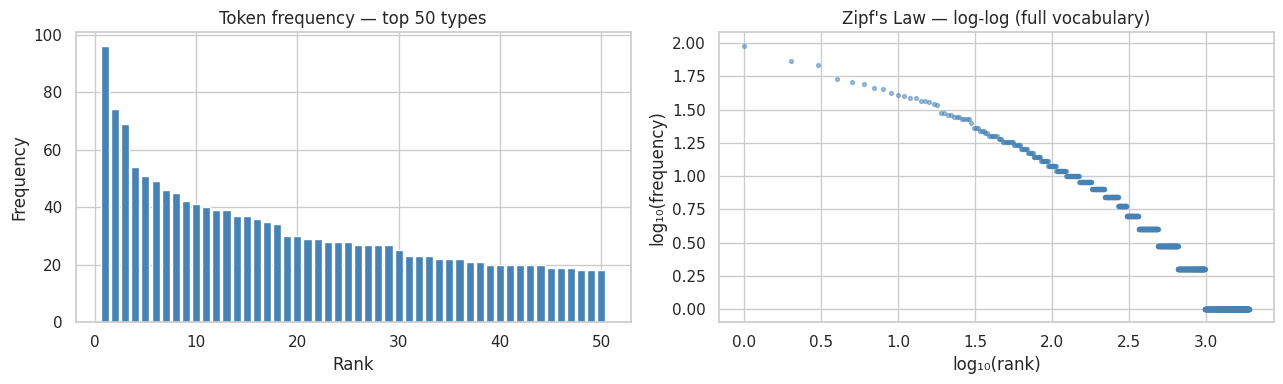

In [16]:
# ── Zipf's Law ─────────────────────────────────────────────────────────────
corpus_freq_sorted = corpus_freq.copy().reset_index(drop=True)
corpus_freq_sorted["rank"] = range(1, len(corpus_freq_sorted) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: raw bar chart, top 50 types
axes[0].bar(corpus_freq_sorted["rank"][:50], corpus_freq_sorted["n"][:50], color="steelblue")
axes[0].set(title="Token frequency — top 50 types", xlabel="Rank", ylabel="Frequency")

# Right: log-log plot over full vocabulary
axes[1].scatter(
    np.log10(corpus_freq_sorted["rank"]),
    np.log10(corpus_freq_sorted["n"]),
    s=8, alpha=0.5, color="steelblue"
)
axes[1].set(title="Zipf's Law — log-log (full vocabulary)",
            xlabel="log₁₀(rank)", ylabel="log₁₀(frequency)")

plt.tight_layout()
plt.show()

## 16. Top Tokens per Document

Plotting the most frequent tokens per document gives a quick visual overview of each document's thematic focus. Documents that share many top tokens are likely thematically similar; documents with highly distinctive top terms address specialized topics.

We use a **faceted horizontal bar chart** — one subplot per document — with tokens sorted by frequency within each facet. This allows direct visual comparison of vocabulary profiles across the corpus.

**What to look for:**
- Which tokens appear in the top 10 across *all* documents? These represent general sustainability vocabulary shared across the corpus.
- Which documents have the most distinctive top terms? What does this suggest about their topic and genre (policy statement vs. operational report vs. strategic foresight)?
- Do any documents show terms you would not expect in a sustainability corpus?

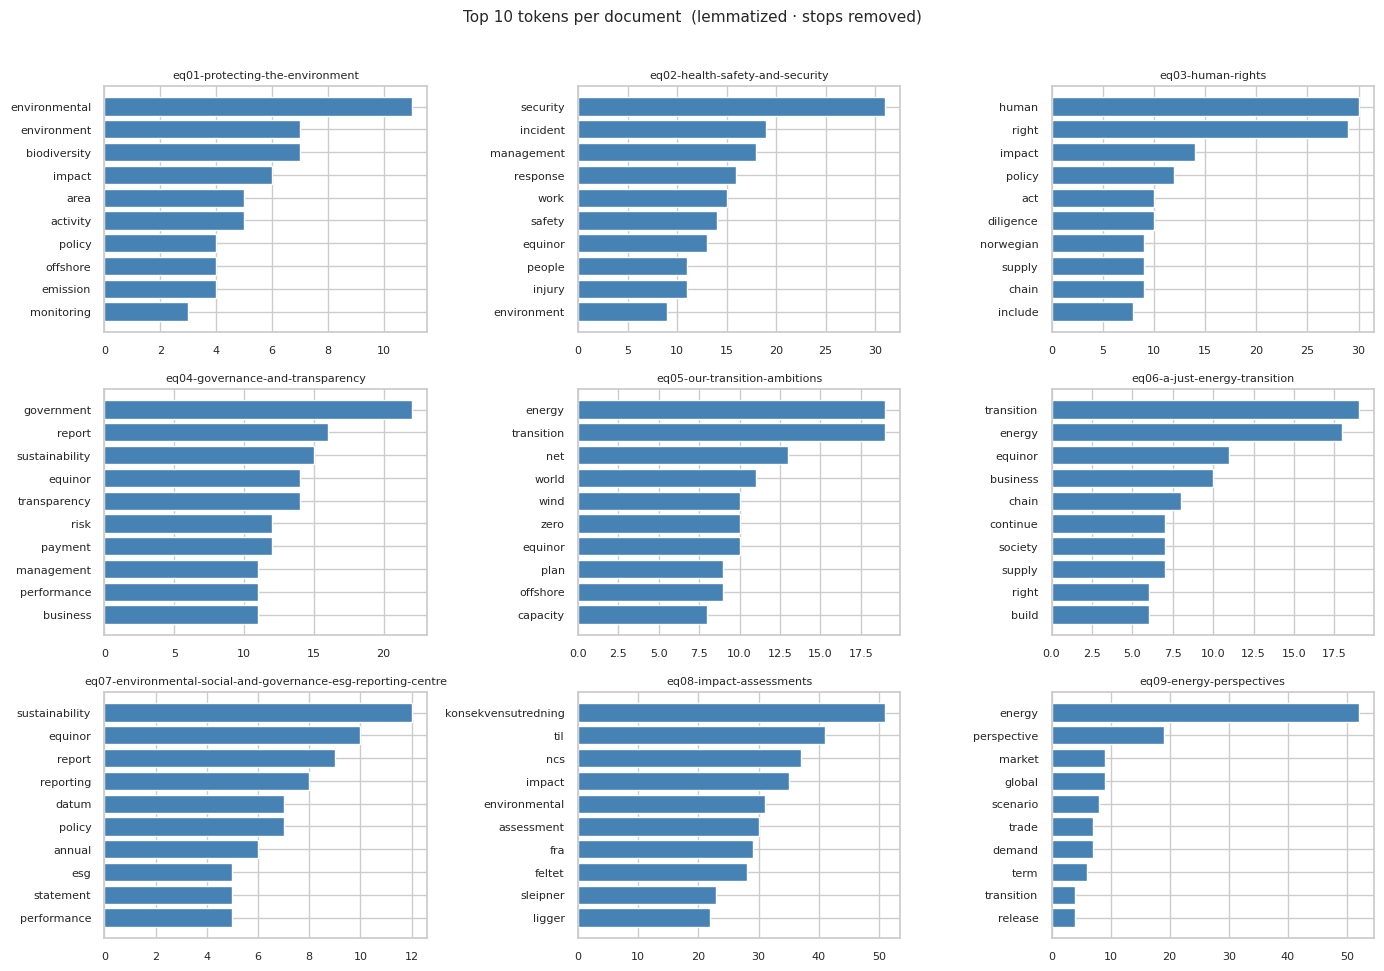

In [17]:
# ── Top 10 tokens per document — faceted horizontal bar chart ─────────────
doc_freq = df_tokens.groupby(["filename", "token"]).size().reset_index(name="n")

top10 = (
    doc_freq.sort_values("n", ascending=False)
    .groupby("filename", group_keys=False)
    .head(10)
)

filenames = sorted(top10["filename"].unique())
ncols = 3
nrows = -(-len(filenames) // ncols)          # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3.2))
axes = axes.flatten()

for i, fname in enumerate(filenames):
    data = top10[top10["filename"] == fname].sort_values("n")
    axes[i].barh(data["token"], data["n"], color="steelblue")
    short = fname.replace("equinor", "eq").replace(".txt", "")
    axes[i].set_title(short, fontsize=8)
    axes[i].tick_params(axis="both", labelsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Top 10 tokens per document  (lemmatized · stops removed)",
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

## 17. Word Cloud

A **word cloud** represents token frequencies visually: the size of each word is proportional to how often it appears in the corpus. It provides an immediate, high-level overview of the dominant vocabulary (Ghosh & Gunning, 2019, ch. 2, "Word Clouds").

Because we have already removed stop words and applied lemmatization, the word cloud should foreground genuine content terms rather than function words.

Word clouds are useful for **exploration and communication** but have real limitations as an analytical tool:
- They cannot convey context, co-occurrence, or sentiment
- They give no information about which documents a word appears in
- Word length influences visual prominence (longer words look larger at the same font size)

Think of a word cloud as a prompt for curiosity — a starting point for questions, not an answer in itself.

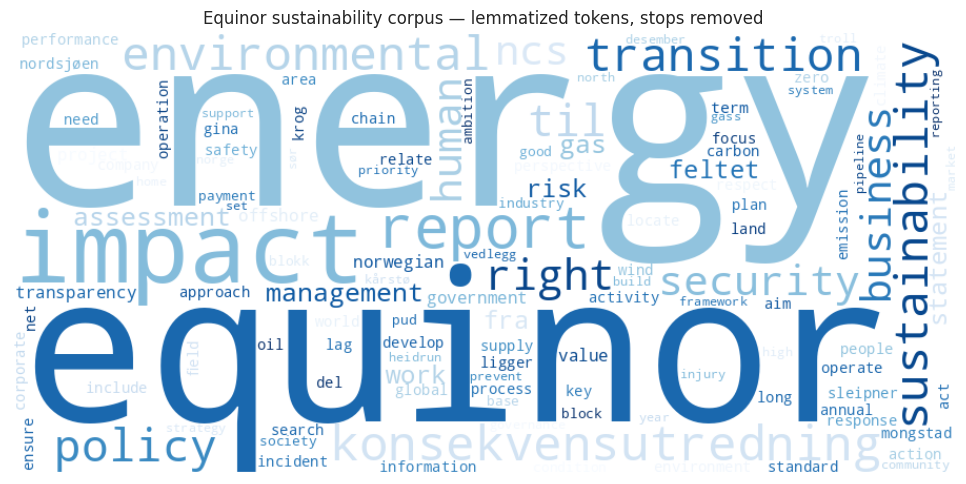

In [18]:
# ── Word cloud ─────────────────────────────────────────────────────────────
try:
    from wordcloud import WordCloud
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "wordcloud"], check=True)
    from wordcloud import WordCloud

freq_dict = dict(zip(corpus_freq["token"], corpus_freq["n"]))
wc = WordCloud(
    width=900, height=420, background_color="white",
    max_words=120, colormap="Blues_r", random_state=42
).generate_from_frequencies(freq_dict)

fig, ax = plt.subplots(figsize=(13, 5))
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
ax.set_title("Equinor sustainability corpus — lemmatized tokens, stops removed", fontsize=12)
plt.tight_layout()
plt.show()

## 18. Preprocessing Choices Matter

The course module (Lab 1 description) emphasises that preprocessing "has significant implications for whether an analysis answers a research question appropriately." Every decision in the pipeline is a methodological choice with consequences for what is visible — and what is invisible — in the data:

| Decision | What it changes |
|----------|----------------|
| **Keep stop words** | Retains grammatical function words; relevant for stylometry, hedging analysis, syntactic research |
| **Remove stop words** | Foregrounds content words; standard for topic and frequency analysis |
| **Lemmatize** | Merges inflected forms (*transition*, *transitioning*, *transitions* → *transition*); improves frequency-based recall |
| **Do not lemmatize** | Preserves morphological distinctions; relevant for grammatical or discourse analysis |
| **Min length = 3** | Removes short but sometimes meaningful terms (*oil*, *gas*, *war*) |

The cell below compares the top 20 tokens under four pipeline configurations for the first document. Use it to make the effect of each decision concrete.

In [19]:
# ── Compare four preprocessing configurations on document 1 ───────────────
sample_doc = nlp(df_texts.iloc[0]["text"])

def get_top(spacy_doc, remove_stops=True, lemmatize=True, min_len=3, top_n=20):
    tokens = []
    for tok in spacy_doc:
        if not tok.is_alpha or len(tok.text) < min_len:
            continue
        if remove_stops and tok.is_stop:
            continue
        tokens.append(tok.lemma_.lower() if lemmatize else tok.lower_)
    return [t for t, _ in Counter(tokens).most_common(top_n)]

configs = {
    "stops removed + lemmatized  ← our pipeline": get_top(sample_doc, True,  True),
    "stops removed, not lemmatized":               get_top(sample_doc, True,  False),
    "stops kept   + lemmatized":                   get_top(sample_doc, False, True),
    "stops kept,   not lemmatized":                get_top(sample_doc, False, False),
}

for name, tokens in configs.items():
    print(f"\n── {name}")
    print(f"   {tokens}")


── stops removed + lemmatized  ← our pipeline
   ['environmental', 'environment', 'biodiversity', 'enno', 'impact', 'area', 'activity', 'offshore', 'emission', 'policy', 'protect', 'sustainability', 'installation', 'monitoring', 'action', 'oil', 'gas', 'grow', 'power', 'sensitive']

── stops removed, not lemmatized
   ['environmental', 'environment', 'biodiversity', 'enno', 'areas', 'offshore', 'emissions', 'activities', 'impact', 'policy', 'sustainability', 'drilling', 'installations', 'monitoring', 'actions', 'protecting', 'oil', 'gas', 'growing', 'power']

── stops kept   + lemmatized
   ['and', 'our', 'the', 'environmental', 'environment', 'biodiversity', 'enno', 'impact', 'area', 'from', 'activity', 'be', 'offshore', 'emission', 'policy', 'protect', 'sustainability', 'installation', 'monitoring', 'action']

── stops kept,   not lemmatized
   ['and', 'our', 'the', 'environmental', 'environment', 'biodiversity', 'enno', 'areas', 'from', 'offshore', 'emissions', 'activities', 'impac

## 19. Summary and Next Steps

We have built a complete text preprocessing pipeline, from raw strings to a tidy, analysis-ready DataFrame:

| Step | Tool | Data structure produced |
|------|------|------------------------|
| Load documents | `pathlib` · `pandas` | `df_texts` |
| Sentence segmentation | spaCy `doc.sents` | `df_sentences` |
| Tokenization | spaCy tokenizer | token objects |
| Stop word removal | `tok.is_stop` | filtered token stream |
| Alphabetic filter + min length | `tok.is_alpha` · `len()` | cleaner token stream |
| Lowercase + lemmatization | `tok.lemma_.lower()` | normalized tokens |
| Tidy DataFrame | pandas | **`df_tokens`** |

**`df_tokens`** — one normalized token per row, indexed by document and sentence — is the foundation for the computational analyses in the assignment: frequency analysis, TF-IDF, KWIC concordancing, and document similarity.

---

### Reflection questions
1. For a study of *how* Equinor hedges its environmental commitments (*may*, *aims to*, *seeks to*), would you keep or remove stop words? Why?
2. The token *transition* appears frequently. Run `df_tokens[df_tokens["token"] == "transition"]` — what sentence and document positions does it come from?
3. Which document in the corpus has the highest type-token ratio? What might this say about its language and genre?
4. Substitute the two synthetic sentences in cell 3 with sentences from your own research area. What preprocessing decisions would you change?

---

**Lab 2** builds on `df_tokens` to extract richer features: named entities (`doc.ents`), part-of-speech distributions (`tok.pos_`), KWIC concordances, and sentiment — and to communicate findings in a reproducible Jupyter notebook report.

The **assignment** (Task 1) asks you to design a qualitative document study of this Equinor corpus; Task 2 asks you to conduct a computational analysis using only the Python standard library — building on the pipeline logic you have practised here.

In [20]:
# ── Save tidy DataFrames for use in Lab 2 ─────────────────────────────────
import os
os.makedirs("output", exist_ok=True)

df_tokens.to_csv("output/df_tokens.tsv",     sep="\t", index=False)
df_sentences.to_csv("output/df_sentences.tsv", sep="\t", index=False)
df_texts[["filename", "n_chars"]].to_csv("output/df_texts.tsv", sep="\t", index=False)

print("Files saved to output/:")
for f in sorted(os.listdir("output")):
    size = os.path.getsize(f"output/{f}")
    print(f"  {f}  ({size:,} bytes)")

print(f"\ndf_tokens — final preview ({len(df_tokens):,} rows):")
display(df_tokens.sample(10, random_state=42).sort_values(["filename", "sentence_id", "token_id"]))

Files saved to output/:
  df_sentences.tsv  (100,802 bytes)
  df_texts.tsv  (431 bytes)
  df_tokens.tsv  (353,686 bytes)

df_tokens — final preview (6,906 rows):


,filename,sentence_id,token_id,token
994,equinor02-health-safety-and-security.txt,58,6,relate
1702,equinor04-governance-and-transparency.txt,1,6,transparency
1718,equinor04-governance-and-transparency.txt,2,6,advantage
1921,equinor04-governance-and-transparency.txt,12,28,embed
2464,equinor05-our-transition-ambitions.txt,3,4,energy
3910,equinor07-environmental-social-and-governance-...,5,1,sustainability
4466,equinor08-impact-assessments.txt,30,5,connection
5480,equinor08-impact-assessments.txt,105,13,norfra
5709,equinor08-impact-assessments.txt,123,2,omfatter
6655,equinor09-energy-perspectives.txt,16,7,insight
